In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv("Student_Performance.csv")
data

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [3]:
data.shape


(25000, 16)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [5]:
data.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='str')

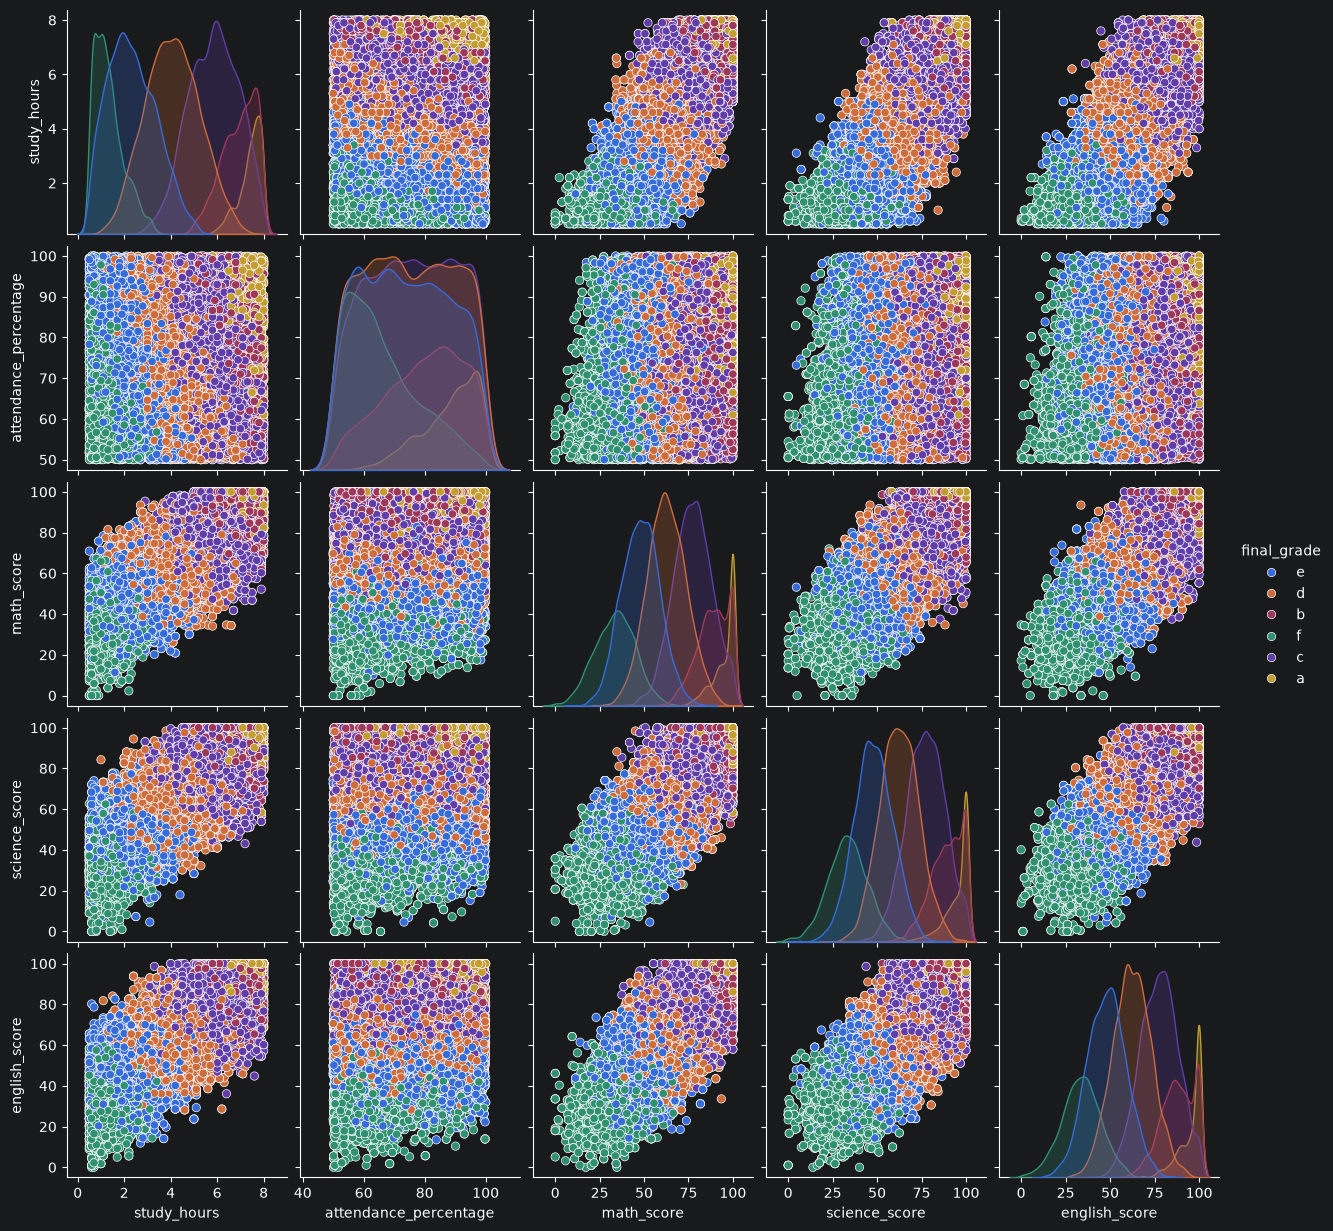

In [9]:
import seaborn as sns

sns.pairplot(
    data[["study_hours","attendance_percentage","math_score","science_score","english_score","final_grade"]],
    hue="final_grade",
)

In [10]:
x = data.drop(["student_id", "overall_score", "final_grade"], axis=1)
y = data["final_grade"]

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = x.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

x = preprocessor.fit_transform(x)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12168\2850693562.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include=["object"]).columns


In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [16]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](6,)","[ 972.,2154.,4910.,5076.,4560.,2328.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](6,)","[0.05,0.11,0.25,0.25,0.23,0.12]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U1](6,)","['a','b','c','d','e','f']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,4.368e-07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,31
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](6, 31)","[[ 0.34, 0.31, 0.35,...,95.36,94.91,95.1 ], [ 0.33, 0.33, 0.34,...,88.48,89.02,87.8 ], [ 0.35, 0.33, 0.32,...,77.14,77.2 ,77.31], [ 0.33, 0.33, 0.34,...,62.72,62.44,62.21], [ 0.32, 0.34, 0.34,...,47.87,47.87,48. ], [ 0.34, 0.32, 0.35,...,33.64,33.49,33.6 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](6, 31)","[[ 0.22, 0.21, 0.23,..., 37.52, 50.56, 41.11], [ 0.22, 0.22, 0.23,..., 77.8 , 80.06, 86.33], [ 0.23, 0.22, 0.22,...,116.9 ,117.4 ,115.18], [ 0.22, 0.22, 0.22,...,118.2 ,119.6 ,120.78], [ 0.22, 0.22, 0.23,...,114.23,118.48,124.71], [ 0.22, 0.22, 0.23,...,130.26,125.3 ,118.47]]"


In [17]:
pred = model.predict(x_test)
pred

array(['d', 'f', 'e', ..., 'd', 'e', 'd'], shape=(5000,), dtype='<U1')

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

0.744
[[161  71   1   0   0   0]
 [ 86 360  96   0   0   0]
 [  0 177 914 160   0   0]
 [  0   0 148 921 166   0]
 [  0   0   0 149 846 117]
 [  0   0   0   0 109 518]]
              precision    recall  f1-score   support

           a       0.65      0.69      0.67       233
           b       0.59      0.66      0.63       542
           c       0.79      0.73      0.76      1251
           d       0.75      0.75      0.75      1235
           e       0.75      0.76      0.76      1112
           f       0.82      0.83      0.82       627

    accuracy                           0.74      5000
   macro avg       0.73      0.74      0.73      5000
weighted avg       0.75      0.74      0.74      5000

